In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving dailyActivity_merged.csv to dailyActivity_merged.csv
Saving dailyCalories_merged.csv to dailyCalories_merged.csv
Saving dailyIntensities_merged.csv to dailyIntensities_merged.csv
Saving dailySteps_merged.csv to dailySteps_merged.csv
Saving hourlyCalories_merged.csv to hourlyCalories_merged.csv
Saving hourlyIntensities_merged.csv to hourlyIntensities_merged.csv
Saving hourlySteps_merged.csv to hourlySteps_merged.csv
Saving sleepDay_merged.csv to sleepDay_merged.csv
Saving weightLogInfo_merged.csv to weightLogInfo_merged.csv


In [ ]:

activity = pd.read_csv("dailyActivity_merged.csv")
sleep = pd.read_csv("sleepDay_merged.csv")
weight = pd.read_csv("weightLogInfo_merged.csv")
steps = pd.read_csv("dailySteps_merged.csv")
calories = pd.read_csv("dailyCalories_merged.csv")


In [ ]:
activity.shape
sleep.shape
weight.shape


(67, 8)

In [ ]:
activity.head()


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [ ]:
activity.columns


Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='object')

In [ ]:
activity.isnull().sum()
sleep.isnull().sum()
weight.isnull().sum()


,0
Id,0
Date,0
WeightKg,0
WeightPounds,0
Fat,65
BMI,0
IsManualReport,0
LogId,0


In [ ]:
weight = weight.drop(columns=['Fat'])


In [ ]:
weight.isnull().sum()


,0
Id,0
Date,0
WeightKg,0
WeightPounds,0
BMI,0
IsManualReport,0
LogId,0


In [ ]:
activity = activity.drop_duplicates()
sleep = sleep.drop_duplicates()
weight = weight.drop_duplicates()


print(activity.columns)


In [ ]:
print(activity.columns)


Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='object')


In [ ]:
activity['ActivityDate'] = pd.to_datetime(activity['ActivityDate'])


sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])

weight['Date'] = pd.to_datetime(weight['Date'])


/tmp/ipykernel_178/901350526.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])
/tmp/ipykernel_178/901350526.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weight['Date'] = pd.to_datetime(weight['Date'])


In [ ]:
activity['ActivityDate'] = pd.to_datetime(activity['ActivityDate'])
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])


In [ ]:
merged_df = activity.merge(
    sleep,
    left_on=['Id','ActivityDate'],
    right_on=['Id','SleepDay'],
    how='left'
)


In [ ]:
merged_df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-12,1.0,327.0,346.0
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,2016-04-13,2.0,384.0,407.0
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,NaT,NaN,NaN,NaN
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,2016-04-15,1.0,412.0,442.0
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,2016-04-16,2.0,340.0,367.0


In [ ]:
### Exploratory Data Analysis
activity['TotalSteps'].mean()


np.float64(7637.9106382978725)

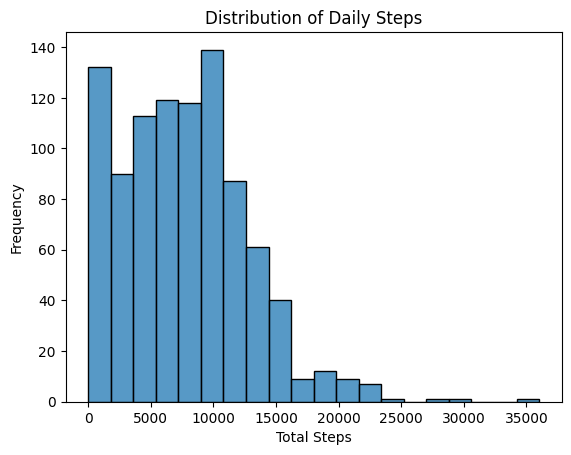

In [ ]:
plt.figure()
sns.histplot(activity['TotalSteps'], bins=20)
plt.title("Distribution of Daily Steps")
plt.xlabel("Total Steps")
plt.ylabel("Frequency")
plt.show()


In [ ]:
###Activity vs Sedentary Time
activity_minutes = activity[['VeryActiveMinutes',
                             'FairlyActiveMinutes',
                             'LightlyActiveMinutes',
                             'SedentaryMinutes']].mean()

print(activity_minutes)



VeryActiveMinutes        21.164894
FairlyActiveMinutes      13.564894
LightlyActiveMinutes    192.812766
SedentaryMinutes        991.210638
dtype: float64


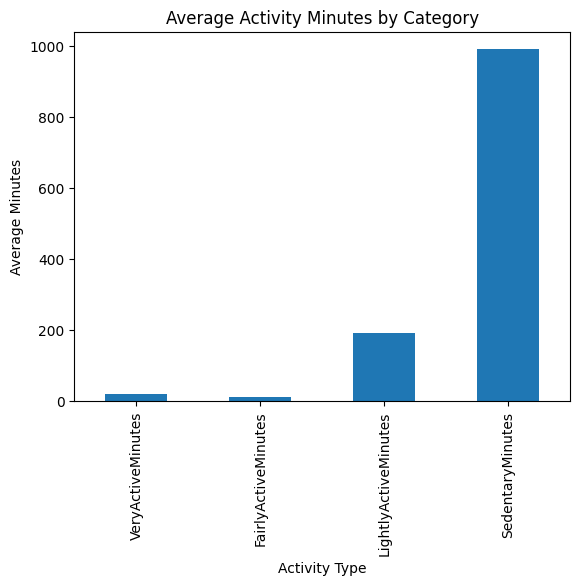

In [ ]:
activity_minutes.plot(kind='bar')
plt.title("Average Activity Minutes by Category")
plt.xlabel("Activity Type")
plt.ylabel("Average Minutes")
plt.show()


In [ ]:
###Sleep Duration
sleep['TotalMinutesAsleep'].mean() / 60



np.float64(6.986219512195122)

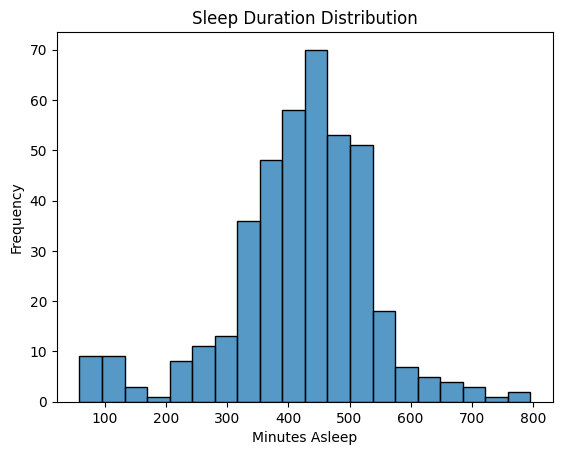

In [ ]:
plt.figure()
sns.histplot(sleep['TotalMinutesAsleep'], bins=20)
plt.title("Sleep Duration Distribution")
plt.xlabel("Minutes Asleep")
plt.ylabel("Frequency")
plt.show()


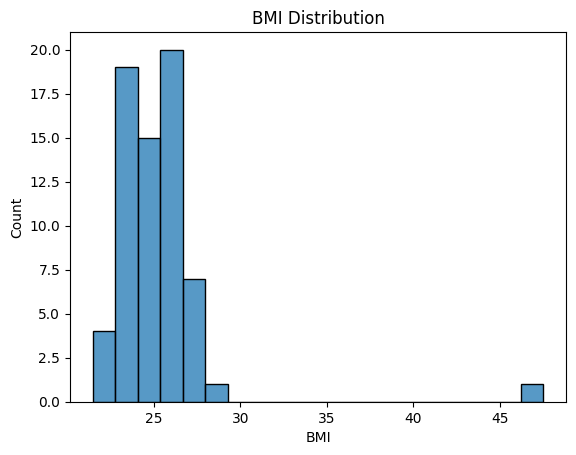

In [ ]:
#BMI Distribution
sns.histplot(weight['BMI'], bins=20)
plt.title("BMI Distribution")
plt.show()


In [ ]:
#BMI Categories
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

weight['BMI_Category'] = weight['BMI'].apply(bmi_category)

bmi_counts = weight['BMI_Category'].value_counts()
print(bmi_counts)


BMI_Category
Normal        34
Overweight    32
Obese          1
Name: count, dtype: int64


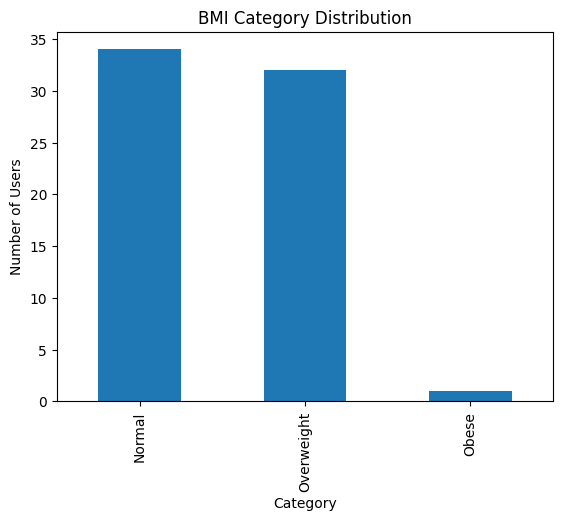

In [ ]:
bmi_counts.plot(kind='bar')
plt.title("BMI Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Users")
plt.show()


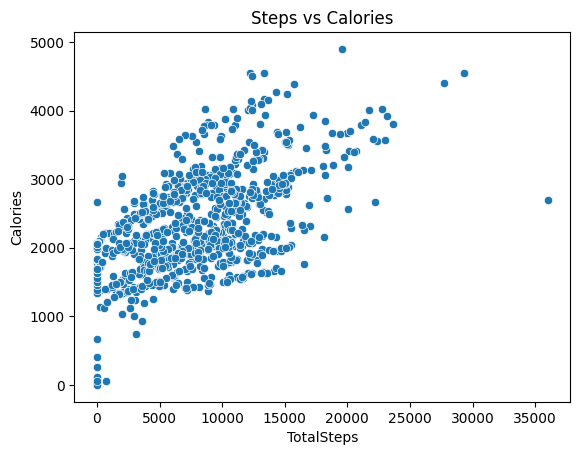

In [ ]:
#Steps vs Calories
sns.scatterplot(x=activity['TotalSteps'], y=activity['Calories'])
plt.title("Steps vs Calories")
plt.show()
